In [ ]:
#**New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.9.2
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [7]:
# Try loading one file

df = pd.read_parquet(r'C:\Users\Ramyata\EDA Assignment - NYC yellow taxi\Datasets and Dictionary-NYC\Datasets and Dictionary\trip_records\2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(r'C:\Users\Ramyata\EDA Assignment - NYC yellow taxi\Datasets and Dictionary-NYC\Datasets and Dictionary\trip_records')

In [11]:
# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()

In [13]:
# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)
        month_df['tpep_pickup_datetime'] = pd.to_datetime(month_df['tpep_pickup_datetime'])
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour

# We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date in month_df['pickup_date'].unique():
            date_data = month_df[month_df['pickup_date'] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                hour_data = date_data[date_data['pickup_hour'] == hour]

                # Sample 5% of the hourly data randomly
                if len(hour_data) > 0:
                    sample = hour_data.sample(frac=0.05, random_state=42)

                # add data of this hour to the dataframe
                    sampled_data = pd.concat([sampled_data, sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True) # we initialised this empty DF earlier
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [15]:
# Store the df in csv/parquet
# df.to_parquet('')

df.to_parquet('NYC_Yellow_Taxi_2023_Sampled.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [17]:
# Load the new data file
import pandas as pd

df = pd.read_parquet('NYC_Yellow_Taxi_2023_Sampled.parquet')

In [19]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [21]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996077 entries, 0 to 1996076
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [23]:
# Fix the index and drop any columns that are not needed
# Fix index
df.reset_index(drop=True, inplace=True)

# Drop helper columns used only for sampling
df.drop(columns=['pickup_date', 'pickup_hour'], inplace=True, errors='ignore')

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [25]:
# Combine the two airport fee columns

df['airport_fee'] = df['airport_fee'].fillna(0) + df['Airport_fee'].fillna(0)
df.drop(columns=['Airport_fee'], inplace=True)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [27]:
# check where values of fare amount are negative

df[df['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [29]:
df = df[df['fare_amount'] >= 0]

Did you notice something different in the `RatecodeID` column for above records?

In [31]:
# Analyse RatecodeID for the negative fare amounts
df_neg = df[df['fare_amount'] < 0]
df_neg['RatecodeID'].value_counts()

Series([], Name: count, dtype: int64)

In [33]:
# Find which columns have negative values
df_neg.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# fix these negative values
df = df[df['fare_amount'] >= 0]
df = df[df['total_amount'] >= 0]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [37]:
# Find the proportion of missing values in each column
missing_prop = df.isna().mean()
missing_prop

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          0.034249
trip_distance            0.000000
RatecodeID               0.034249
store_and_fwd_flag       0.034249
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     0.034249
airport_fee              0.000000
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [39]:
# Display the rows with null values
df[df['passenger_count'].isna()]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.0
15,2,2023-01-01 00:41:50,2023-01-01 01:14:50,NaN,10.77,NaN,None,151,106,0,45.38,0.0,0.5,11.19,6.55,1.0,67.12,NaN,0.0
42,2,2023-01-01 00:37:21,2023-01-01 00:54:18,NaN,4.52,NaN,None,114,262,0,25.38,0.0,0.5,0.00,0.00,1.0,29.38,NaN,0.0
43,2,2023-01-01 00:44:03,2023-01-01 01:13:49,NaN,9.19,NaN,None,239,256,0,40.00,0.0,0.5,2.20,0.00,1.0,46.20,NaN,0.0
46,2,2023-01-01 00:50:55,2023-01-01 01:19:06,NaN,2.74,NaN,None,90,48,0,18.48,0.0,0.5,3.37,0.00,1.0,25.85,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995977,1,2023-09-29 17:25:12,2023-09-29 17:41:17,NaN,2.30,NaN,None,141,239,0,16.30,2.5,0.5,3.42,0.00,1.0,26.22,NaN,0.0
1995979,1,2023-09-29 17:47:45,2023-09-29 18:02:28,NaN,0.00,NaN,None,161,144,0,46.90,0.0,0.5,0.00,0.00,1.0,50.90,NaN,0.0
1995987,1,2023-09-29 18:45:33,2023-09-29 19:07:42,NaN,0.00,NaN,None,238,186,0,46.79,0.0,0.5,0.00,0.00,1.0,50.79,NaN,0.0
1996021,2,2023-09-29 19:16:04,2023-09-29 19:40:35,NaN,3.98,NaN,None,107,43,0,28.76,0.0,0.5,6.55,0.00,1.0,39.31,NaN,0.0


In [41]:
# Impute NaN values in 'passenger_count'
df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [43]:
# Handle zero values in passenger_count
df.loc[df['passenger_count'] == 0, 'passenger_count'] = df['passenger_count'].median()

# Fix missing values in 'RatecodeID'
df['RatecodeID'].fillna(1, inplace=True)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [45]:
# handle null values in congestion_surcharge
df['congestion_surcharge'].fillna(0, inplace=True)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [47]:
# Handle any remaining missing values

df.isna().sum()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count              0
trip_distance                0
RatecodeID                   0
store_and_fwd_flag       68361
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge         0
airport_fee                  0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [49]:
# Describe the data and check if there are any potential outliers present
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,1.995998e+06,1995998,1995998,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06,1.995998e+06
mean,1.733053e+00,2023-07-02 20:00:53.605200,2023-07-02 20:18:19.667617,1.372140e+00,3.860344e+00,1.612069e+00,1.652883e+02,1.640624e+02,1.163778e+00,1.991493e+01,1.587889e+00,4.953125e-01,3.546513e+00,5.971222e-01,9.990486e-01,2.897791e+01,2.228806e+00,1.380229e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.500000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:10:55.750000,2023-04-02 16:29:53.250000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-27 15:46:54,2023-06-27 16:03:15,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-06 19:39:12.750000,2023-10-06 19:54:19.250000,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00
std,4.477343e-01,NaN,NaN,8.642211e-01,1.281479e+02,7.260732e+00,6.399622e+01,6.980345e+01,5.082065e-01,1.029519e+02,1.829184e+00,4.847646e-02,4.054004e+00,2.189397e+00,2.841968e-02,1.038531e+02,7.774561e-01,4.575664e-01


In [51]:
# Check for potential out of place values in various columns
df[['fare_amount', 'trip_distance', 'total_amount', 'tip_amount', 'passenger_count']].quantile([0.01, 0.05, 0.95, 0.99])

,fare_amount,trip_distance,total_amount,tip_amount,passenger_count
0.01,4.4,0.00,8.70,0.00,1.0
0.05,5.8,0.46,11.50,0.00,1.0
0.95,70.0,15.30,82.69,12.00,3.0
0.99,77.2,20.22,104.15,17.65,5.0


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [53]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]

In [55]:
# Continue with outlier handling

# 1. Remove trips where trip_distance is nearly 0 but fare_amount is very high (>300)
df = df[~((df['trip_distance'] <= 0.1) & (df['fare_amount'] > 300))]

# 2. Remove trips where trip_distance and fare_amount are 0 but pickup and dropoff locations are different
df = df[~(
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
)]

# 3. Remove trips with unrealistically large trip distances (>250 miles)
df = df[df['trip_distance'] <= 250]

# 4. Remove entries with invalid payment_type (0 is not defined)
df = df[df['payment_type'] != 0]

In [57]:
# Do any columns need standardising?

# Ensure datetime columns are in datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Standardise store_and_fwd_flag values
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].str.upper().str.strip()

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [59]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: categorical
* `tpep_pickup_datetime`: datetime
* `tpep_dropoff_datetime`: datetime
* `passenger_count`: numerical 
* `trip_distance`: numerical 
* `RatecodeID`: categorical 
* `PULocationID`: categorical
* `DOLocationID`:categorical 
* `payment_type`: categorical 
* `pickup_hour`:numerical 
* `trip_duration`: numerical (continuous)


The following monetary parameters belong in the same category, is it categorical or numerical?
---> These are numerical (continuous) variables, not categorical

* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

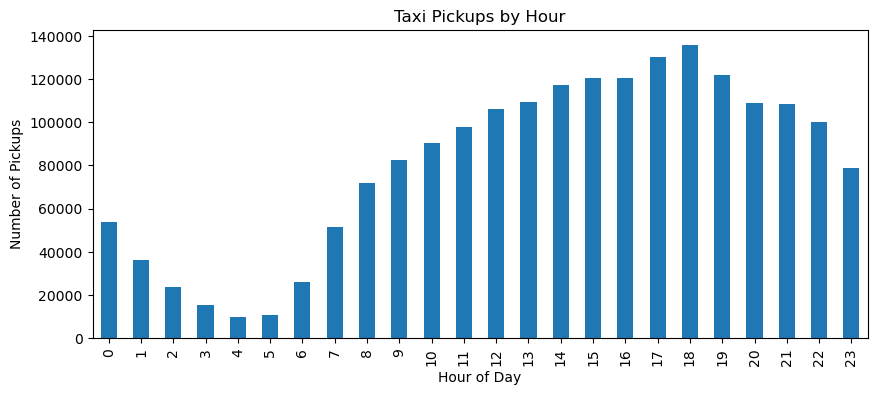

In [61]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

df['pickup_hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.title('Taxi Pickups by Hour')
plt.show()

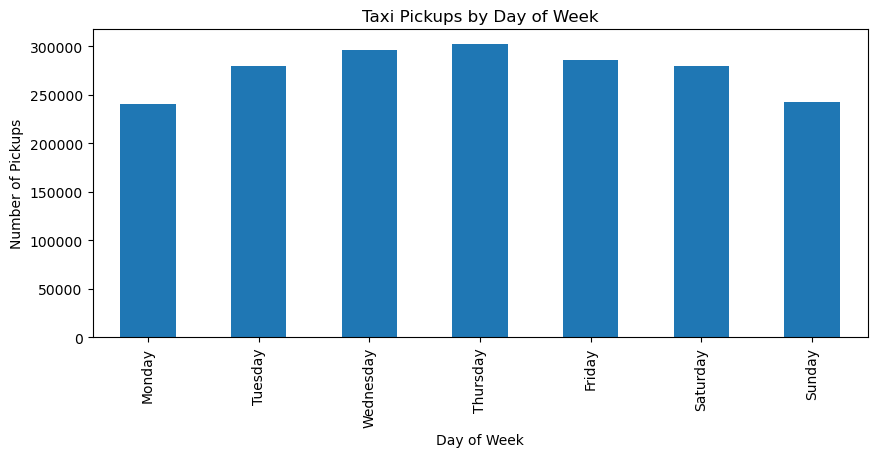

In [63]:
# Find and show the daily trends in taxi pickups (days of the week)

order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['pickup_day'].value_counts().reindex(order_days).plot(kind='bar', figsize=(10,4))
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.title('Taxi Pickups by Day of Week')
plt.show()

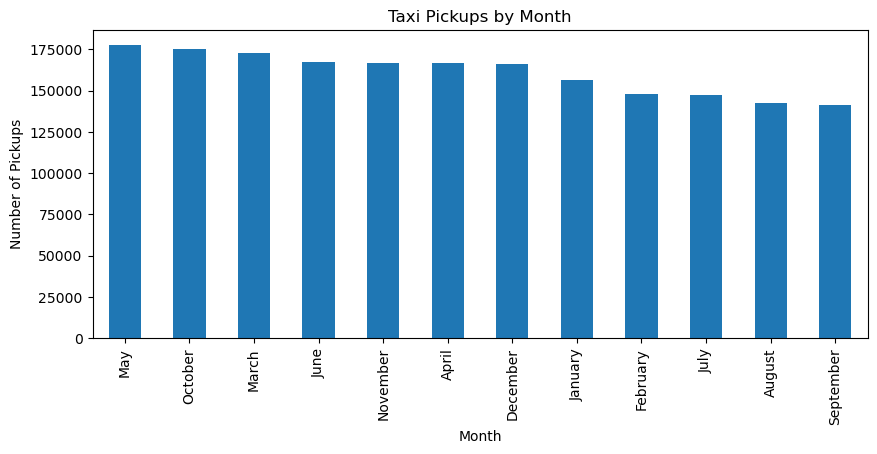

In [65]:
# Show the monthly trends in pickups

df['pickup_month'].value_counts().plot(kind='bar', figsize=(10,4))
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Taxi Pickups by Month')
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [67]:
# Analyse the above parameters
df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']].describe()

,fare_amount,tip_amount,total_amount,trip_distance
count,1.927500e+06,1.927500e+06,1.927500e+06,1.927500e+06
mean,1.981172e+01,3.572756e+00,2.893529e+01,3.444792e+00
std,1.047077e+02,4.068541e+00,1.056072e+02,4.545210e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.300000e+00,1.000000e+00,1.596000e+01,1.050000e+00
50%,1.350000e+01,2.860000e+00,2.100000e+01,1.780000e+00
75%,2.190000e+01,4.450000e+00,3.070000e+01,3.370000e+00
max,1.431635e+05,2.230800e+02,1.431675e+05,2.048600e+02


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

In [69]:
# Check zero and negative values
(df[['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']] <= 0).sum()

fare_amount         527
tip_amount       431773
total_amount        271
trip_distance     24092
dtype: int64

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [71]:
# Create a df with non zero entries for the selected parameters.

df_financial = df[ (df['fare_amount'] > 0) &(df['total_amount'] > 0) & (df['trip_distance'] > 0)]

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [73]:
# Group data by month and analyse monthly revenue

df['pickup_month_num'] = df['tpep_pickup_datetime'].dt.month
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()

monthly_revenue = (df.groupby(['pickup_month_num', 'pickup_month_name'])['total_amount'].sum().reset_index().sort_values('pickup_month_num'))

monthly_revenue

,pickup_month_num,pickup_month_name,total_amount
0,1,January,4267848.15
1,2,February,4036267.85
2,3,March,4865137.60
3,4,April,4776516.61
4,5,May,5202550.92
5,6,June,4895486.31
6,7,July,4265287.79
7,8,August,4159739.27
8,9,September,4382095.84
9,10,October,5218020.31


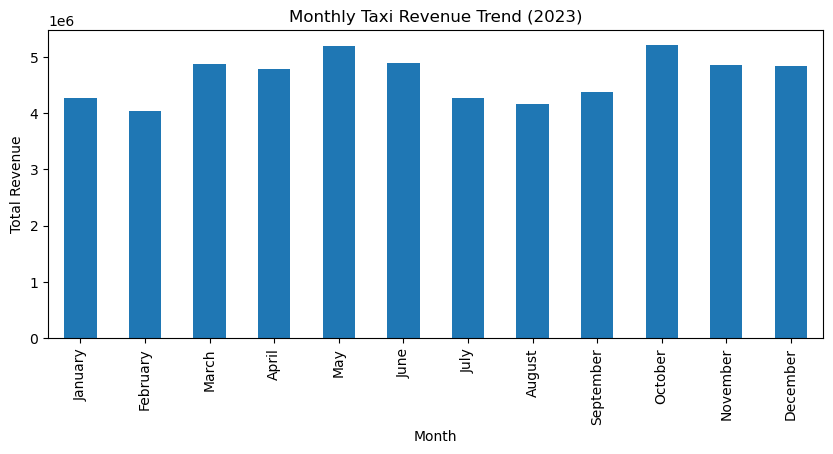

In [75]:
monthly_revenue.plot( x='pickup_month_name',y='total_amount',kind='bar',figsize=(10,4),legend=False)
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Taxi Revenue Trend (2023)')
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [77]:
# Calculate proportion of each quarter

df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.to_period('Q')

quarterly_revenue = (df.groupby('pickup_quarter')['total_amount'].sum().reset_index())

# Calculate proportion
quarterly_revenue['revenue_proportion'] = (quarterly_revenue['total_amount'] /quarterly_revenue['total_amount'].sum())

quarterly_revenue


,pickup_quarter,total_amount,revenue_proportion
0,2022Q4,13.50,2.420536e-07
1,2023Q1,13169253.60,2.361233e-01
2,2023Q2,14874553.84,2.666992e-01
3,2023Q3,12807122.90,2.296304e-01
4,2023Q4,14921833.32,2.675469e-01


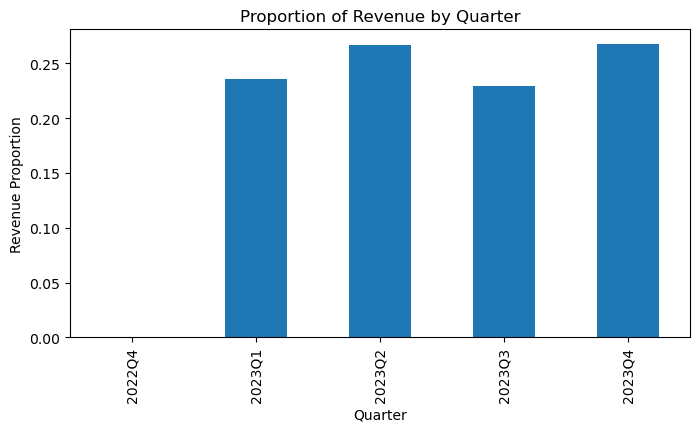

In [79]:
quarterly_revenue.plot(x='pickup_quarter', y='revenue_proportion', kind='bar', figsize=(8,4),legend=False)
plt.xlabel('Quarter')
plt.ylabel('Revenue Proportion')
plt.title('Proportion of Revenue by Quarter')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

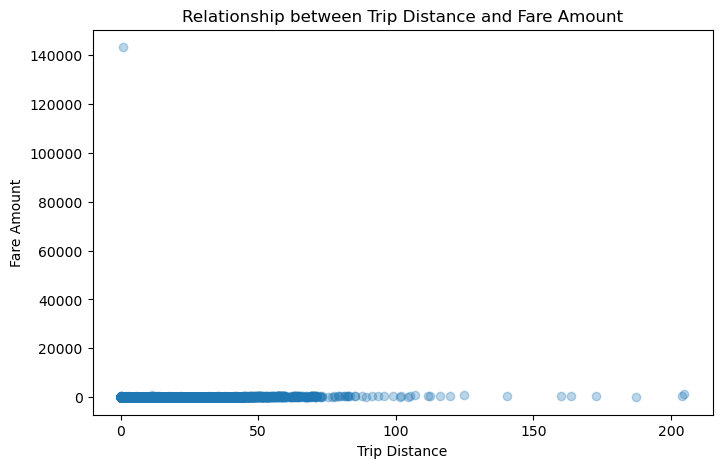

In [81]:
# Show how trip fare is affected by distance

# Remove zero-distance trips
df_distance = df[df['trip_distance'] > 0]

# Scatter plot
plt.figure(figsize=(8,5))
plt.scatter(df_distance['trip_distance'], df_distance['fare_amount'], alpha=0.3)
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Relationship between Trip Distance and Fare Amount')
plt.show()

In [83]:
# Correlation between trip_distance and fare_amount
correlation = df_distance['trip_distance'].corr(df_distance['fare_amount'])
correlation

0.1602449781553957

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [85]:
# Create trip duration in minutes
df['trip_duration'] = ( df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# Remove non-positive durations
df_duration = df[df['trip_duration'] > 0]

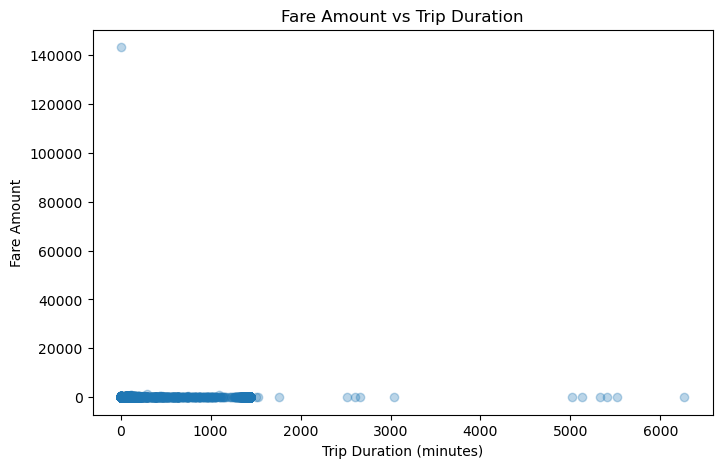

0.045837699805851145

In [87]:
# Show relationship between fare and trip duration
plt.figure(figsize=(8,5))
plt.scatter(df_duration['trip_duration'], df_duration['fare_amount'], alpha=0.3)
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Trip Duration')
plt.show()

# Correlation
df_duration['trip_duration'].corr(df_duration['fare_amount'])

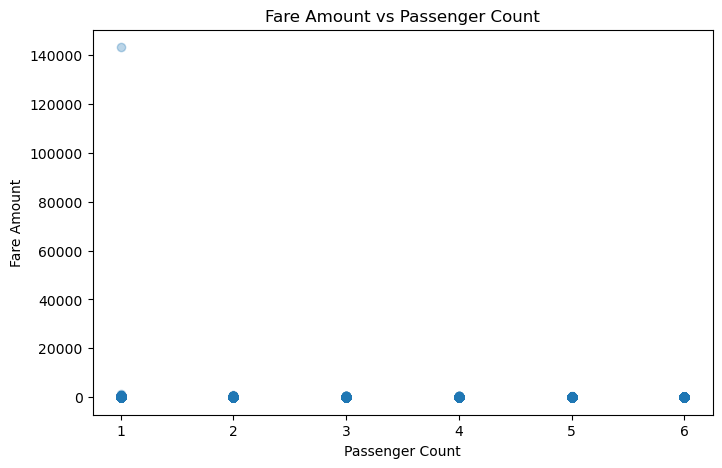

0.007461462258646217

In [89]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(8,5))
plt.scatter(df['passenger_count'], df['fare_amount'], alpha=0.3)
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Passenger Count')
plt.show()

# Correlation
df['passenger_count'].corr(df['fare_amount'])

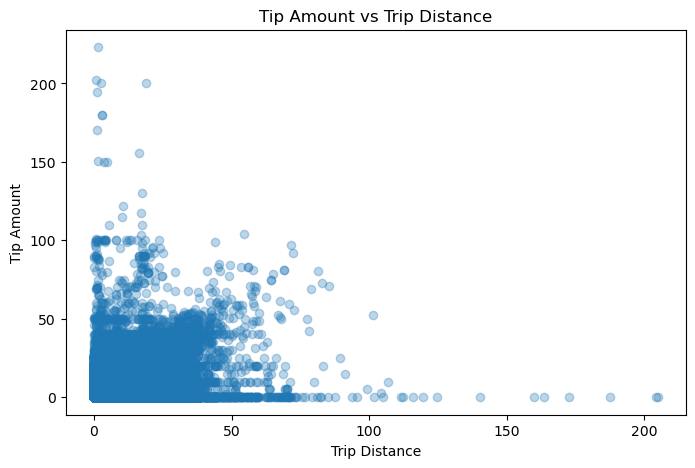

0.585655033403085

In [91]:
# Show relationship between tip and trip distance
df_tip = df[(df['trip_distance'] > 0) & (df['tip_amount'] >= 0)]

plt.figure(figsize=(8,5))
plt.scatter(df_tip['trip_distance'], df_tip['tip_amount'], alpha=0.3)
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip Amount vs Trip Distance')
plt.show()

# Correlation
df_tip['trip_distance'].corr(df_tip['tip_amount'])

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [93]:
# Analyse the distribution of different payment types
payment_dist = df['payment_type'].value_counts().sort_index()
payment_dist

payment_type
1    1570596
2     333048
3       9451
4      14405
Name: count, dtype: int64

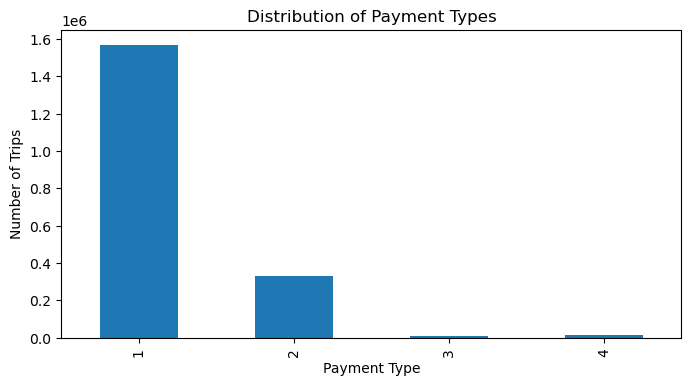

In [95]:
payment_dist.plot(kind='bar', figsize=(8,4))
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [97]:
# !pip install geopandas
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [99]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file(r'C:/Users/Ramyata/EDA Assignment - NYC yellow taxi/Datasets and Dictionary-NYC/Datasets and Dictionary/taxi_zones/taxi_zones.shp')

zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


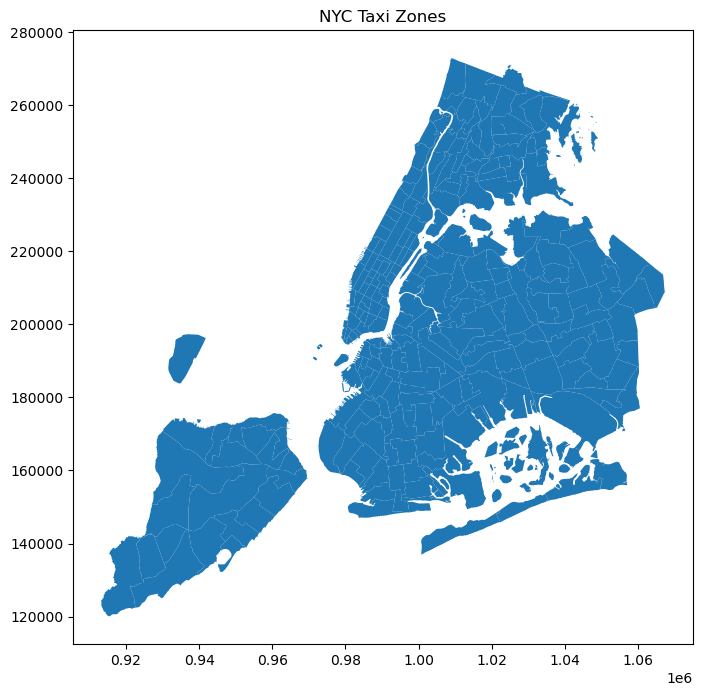

In [101]:
# print(zones.info())
print(zones.info())

# zones.plot()
zones.plot(figsize=(8,8))
plt.title('NYC Taxi Zones')
plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [103]:
# Merge zones and trip records using locationID and PULocationID

df = df.merge(zones[['LocationID', 'zone', 'borough']],left_on='PULocationID',right_on='LocationID', how='left')

# Rename columns for clarity
df.rename(columns={ 'zone': 'PU_zone', 'borough': 'PU_borough'},inplace=True)

# Drop duplicate LocationID column
df.drop(columns=['LocationID'], inplace=True)

In [104]:
df[['PULocationID', 'PU_zone', 'PU_borough']].head()

,PULocationID,PU_zone,PU_borough
0,138,LaGuardia Airport,Queens
1,161,Midtown Center,Manhattan
2,237,Upper East Side South,Manhattan
3,143,Lincoln Square West,Manhattan
4,246,West Chelsea/Hudson Yards,Manhattan


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [107]:
# Group data by location and calculate the number of trips

trips_per_location = (df.groupby('PULocationID').size().reset_index(name='total_trips'))

trips_per_location.head()

,PULocationID,total_trips
0,1,219
1,2,2
2,3,43
3,4,1961
4,5,14


In [109]:
# View with zone names
trips_per_location = trips_per_location.merge(zones[['LocationID', 'zone', 'borough']],left_on='PULocationID',right_on='LocationID', how='left').drop(columns=['LocationID'])

trips_per_location.head()

,PULocationID,total_trips,zone,borough
0,1,219,Newark Airport,EWR
1,2,2,Jamaica Bay,Queens
2,3,43,Allerton/Pelham Gardens,Bronx
3,4,1961,Alphabet City,Manhattan
4,5,14,Arden Heights,Staten Island


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [111]:
# Merge trip counts back to the zones GeoDataFrame

zones_trips = zones.merge(trips_per_location,left_on='LocationID',right_on='PULocationID',how='left')

# Replace NaN trip counts with 0 (zones with no trips)
zones_trips['total_trips'] = zones_trips['total_trips'].fillna(0)

zones_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone_x,LocationID,borough_x,geometry,PULocationID,total_trips,zone_y,borough_y
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,219.0,Newark Airport,EWR
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0,Jamaica Bay,Queens
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,43.0,Allerton/Pelham Gardens,Bronx
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1961.0,Alphabet City,Manhattan
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,14.0,Arden Heights,Staten Island


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

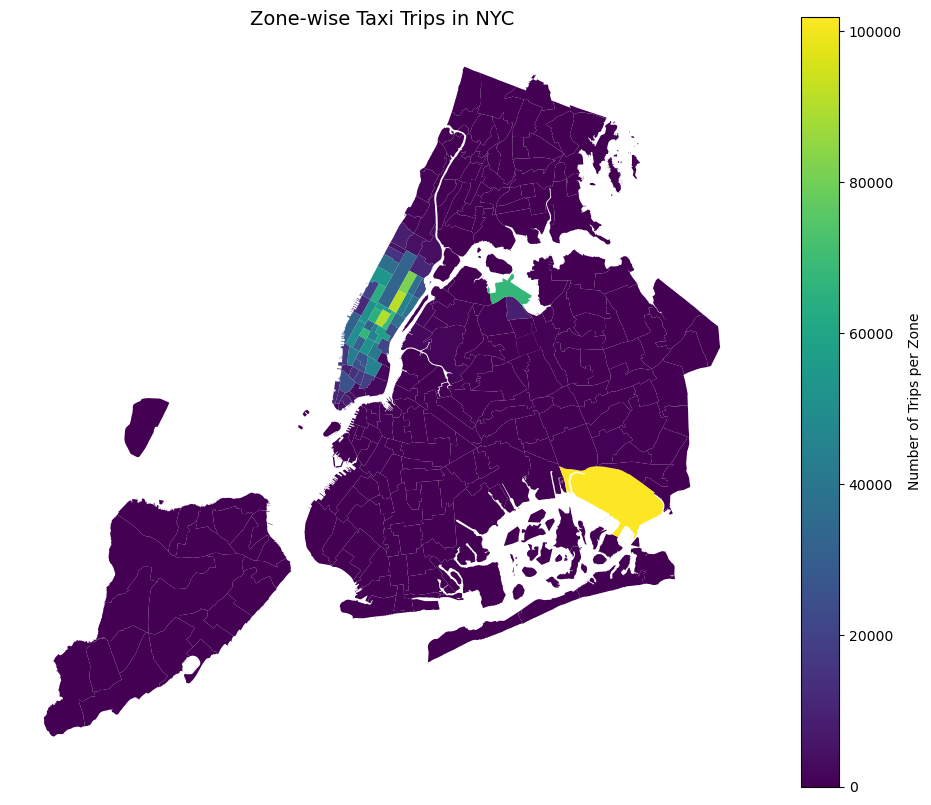

In [113]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones_trips.plot(column='total_trips', ax=ax, legend=True,legend_kwds={ 'label': "Number of Trips per Zone",'orientation': "vertical" })

ax.set_title('Zone-wise Taxi Trips in NYC', fontsize=14)
ax.axis('off')
plt.show()

In [115]:
# Display zones sorted by number of trips
zones_trips_sorted = zones_trips.sort_values(by='total_trips', ascending=False)
zones_trips_sorted.head()

,OBJECTID,Shape_Leng,Shape_Area,zone_x,LocationID,borough_x,geometry,PULocationID,total_trips,zone_y,borough_y
133,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,101914.0,JFK Airport,Queens
238,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,91474.0,Upper East Side South,Manhattan
162,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,90469.0,Midtown Center,Manhattan
237,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,81628.0,Upper East Side North,Manhattan
163,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,69161.0,Midtown East,Manhattan


In [117]:
zones_trips_sorted[['LocationID', 'total_trips']].head()

,LocationID,total_trips
133,132,101914.0
238,237,91474.0
162,161,90469.0
237,236,81628.0
163,162,69161.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [119]:
# Find routes which have the slowest speeds at different times of the day

# Create pickup hour if not already present
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [121]:
# Calculate average duration and distance per route per hour
route_hour_stats = ( df.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']) .agg( avg_duration=('trip_duration', 'mean'), avg_distance=('trip_distance', 'mean')).reset_index())

In [123]:
# Speed = distance / duration (convert minutes to hours)
route_hour_stats['avg_speed_mph'] = ( route_hour_stats['avg_distance'] /(route_hour_stats['avg_duration'] / 60))

In [125]:
# Remove invalid or zero speeds
route_hour_stats = route_hour_stats[route_hour_stats['avg_speed_mph'] > 0]

# Find slowest routes (lowest speed) per hour
slow_routes = (route_hour_stats.sort_values('avg_speed_mph').groupby('pickup_hour').head(5))

slow_routes.head()


,PULocationID,DOLocationID,pickup_hour,avg_duration,avg_distance,avg_speed_mph
104594,232,65,13,5522.433333,0.490000,0.005324
117363,243,264,17,1389.550000,0.180000,0.007772
91957,207,207,10,1.015351,0.000263,0.015551
62676,142,142,5,1413.550000,0.560000,0.023770
122988,258,258,1,45.750000,0.020000,0.026230


How does identifying high-traffic, high-demand routes help us?

Identifying high-traffic and high-demand routes helps taxi operators improve efficiency by placing more cabs where demand is high, reducing waiting and idle time. These routes also highlight congestion hotspots, helping in better route planning. From a business perspective, such routes can be used for dynamic pricing to increase revenue. Overall, this leads to better service availability for passengers and improved earnings for drivers.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

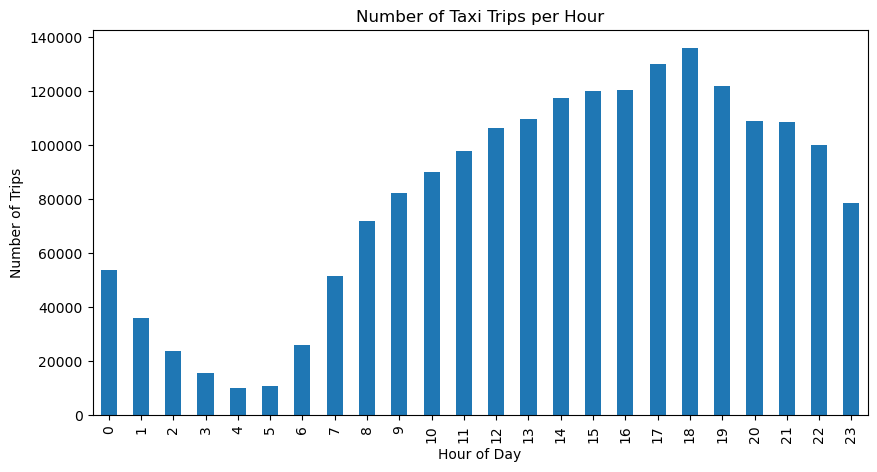

(18, 135945)

In [127]:
# Visualise the number of trips per hour and find the busiest hour

# Extract pickup hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Calculate number of trips per hour
hourly_trips = df['pickup_hour'].value_counts().sort_index()

# Plot trips per hour
plt.figure(figsize=(10, 5))
hourly_trips.plot(kind='bar')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Number of Taxi Trips per Hour')
plt.show()

# Find busiest hour
busiest_hour = hourly_trips.idxmax()
busiest_hour_trips = hourly_trips.max()

busiest_hour, busiest_hour_trips

In [133]:
# Get top 5 busiest hours
top_5_hours = hourly_trips.sort_values(ascending=False).head(5)

top_5_hours

pickup_hour
18    135945
17    130071
19    121989
16    120303
15    120286
Name: count, dtype: int64

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [135]:
# Scale up the number of trips
sample_fraction = 0.05   

actual_trips = top_5_hours / sample_fraction
actual_trips

pickup_hour
18    2718900.0
17    2601420.0
19    2439780.0
16    2406060.0
15    2405720.0
Name: count, dtype: float64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

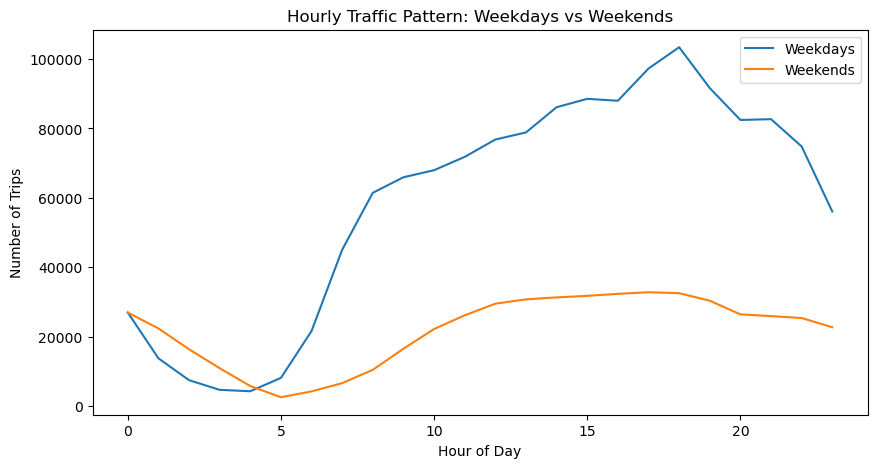

In [137]:
# Compare traffic trends for the week days and weekends

# Extract day of week (0 = Monday, 6 = Sunday)
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

# Create weekday and weekend columns
df['is_weekend'] = df['day_of_week'].isin([5, 6])  # 5=Saturday, 6=Sunday

# Separate weekday and weekend data
weekday_df = df[df['is_weekend'] == False]
weekend_df = df[df['is_weekend'] == True]

# Trips per hour for weekdays
weekday_hourly = weekday_df['pickup_hour'].value_counts().sort_index()

# Trips per hour for weekends
weekend_hourly = weekend_df['pickup_hour'].value_counts().sort_index()

# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(weekday_hourly.index, weekday_hourly.values, label='Weekdays')
plt.plot(weekend_hourly.index, weekend_hourly.values, label='Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Traffic Pattern: Weekdays vs Weekends')
plt.legend()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

On weekdays, peak traffic is observed during morning and evening office hours.

On weekends, higher demand is seen in the late morning and night hours.

Weekend traffic is more evenly distributed compared to weekdays, which show sharp peaks

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones

In [139]:
# Top 10 pickup zones by total pickups
top10_pickup_zones = (df.groupby('PU_zone').size().sort_values(ascending=False).head(10))

top10_pickup_zones

PU_zone
JFK Airport                     101914
Upper East Side South            91474
Midtown Center                   90469
Upper East Side North            81628
Midtown East                     69161
LaGuardia Airport                67570
Penn Station/Madison Sq West     66821
Times Sq/Theatre District        64576
Lincoln Square East              64055
Murray Hill                      57319
dtype: int64

In [141]:
# Merge dropoff zones into df
df = df.merge(zones[['LocationID', 'zone']],left_on='DOLocationID',right_on='LocationID',how='left')

# Rename for clarity
df.rename(columns={'zone': 'DO_zone'}, inplace=True)

# Drop extra column
df.drop(columns=['LocationID'], inplace=True)

In [143]:
# Top 10 dropoff zones
top10_dropoff_zones = (df.groupby('DO_zone').size().sort_values(ascending=False).head(10))

top10_dropoff_zones

DO_zone
Upper East Side North        85557
Upper East Side South        81565
Midtown Center               75458
Times Sq/Theatre District    59442
Murray Hill                  57053
Midtown East                 54959
Lincoln Square East          54168
Upper West Side South        53940
Lenox Hill West              50973
East Chelsea                 48757
dtype: int64

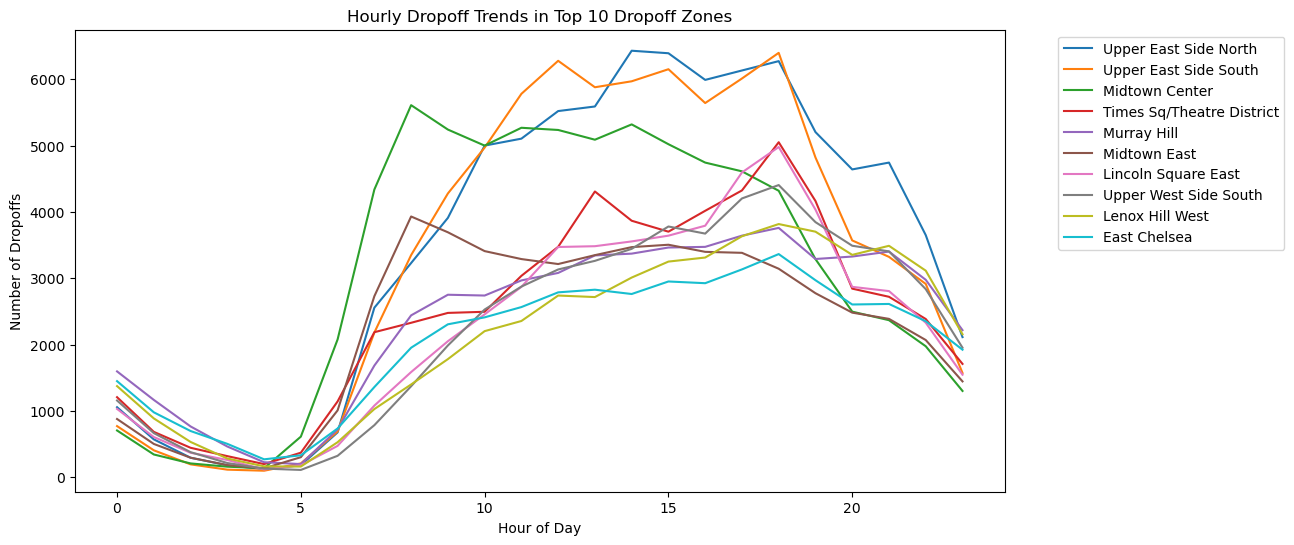

In [145]:
# Hourly dropoff trends
dropoff_trends = (df[df['DO_zone'].isin(top10_dropoff_zones.index)].groupby(['DO_zone', 'pickup_hour']).size().reset_index(name='count'))

plt.figure(figsize=(12,6))

for zone in top10_dropoff_zones.index:
    zone_data = dropoff_trends[dropoff_trends['DO_zone'] == zone]
    plt.plot(zone_data['pickup_hour'], zone_data['count'], label=zone)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Dropoffs')
plt.title('Hourly Dropoff Trends in Top 10 Dropoff Zones')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [147]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickup_counts = df['PULocationID'].value_counts()

dropoff_counts = df['DOLocationID'].value_counts()

In [149]:
zone_counts = pd.DataFrame({'pickups': pickup_counts,'dropoffs': dropoff_counts})


In [151]:
zone_counts.fillna(0, inplace=True)

In [153]:
zone_counts['pickup_drop_ratio'] = zone_counts['pickups'] / zone_counts['dropoffs']

In [155]:
zone_counts.replace([np.inf, -np.inf], np.nan, inplace=True)
zone_counts.dropna(inplace=True)

In [157]:
top_10_high = zone_counts.sort_values(
    by='pickup_drop_ratio',
    ascending=False).head(10)

In [159]:
top_10_low = zone_counts.sort_values(by='pickup_drop_ratio',ascending=True).head(10)


In [161]:
print("Top 10 Highest Pickup/Dropoff Ratios")
print(top_10_high)

print("\nTop 10 Lowest Pickup/Dropoff Ratios")
print(top_10_low)

Top 10 Highest Pickup/Dropoff Ratios
      pickups  dropoffs  pickup_drop_ratio
70     8785.0    1053.0           8.342830
132  102114.0   22105.0           4.619498
138   67682.0   23388.0           2.893877
186   66831.0   42280.0           1.580676
114   25421.0   18472.0           1.376191
43    32375.0   23584.0           1.372753
249   42553.0   32094.0           1.325886
162   69165.0   54959.0           1.258484
161   90476.0   75458.0           1.199025
100   31746.0   26652.0           1.191130

Top 10 Lowest Pickup/Dropoff Ratios
     pickups  dropoffs  pickup_drop_ratio
99       0.0       3.0           0.000000
30       0.0      18.0           0.000000
176      0.0      12.0           0.000000
245      0.0      31.0           0.000000
27       1.0      40.0           0.025000
221      1.0      35.0           0.028571
257     29.0     796.0           0.036432
1      219.0    5607.0           0.039058
115      1.0      23.0           0.043478
198     55.0    1050.0           

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [164]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
night_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]

In [166]:
top_night_pickups = (night_df['PULocationID'].value_counts().head(10))

top_night_pickups

PULocationID
79     16377
132    15374
249    13160
48     10982
148    10165
114     9227
230     8662
186     7336
164     6452
68      6349
Name: count, dtype: int64

In [168]:
top_night_dropoffs = (night_df['DOLocationID'].value_counts().head(10))

top_night_dropoffs

DOLocationID
79     8757
48     7235
170    6626
68     6145
107    6039
141    5549
249    5210
263    5204
230    4923
148    4618
Name: count, dtype: int64

In [170]:
top_pickup_zones = top_night_pickups.reset_index()
top_pickup_zones.columns = ['LocationID', 'Night_Pickups']

top_pickup_zones.merge(zones[['LocationID', 'zone']],on='LocationID',how='left')

,LocationID,Night_Pickups,zone
0,79,16377,East Village
1,132,15374,JFK Airport
2,249,13160,West Village
3,48,10982,Clinton East
4,148,10165,Lower East Side
5,114,9227,Greenwich Village South
6,230,8662,Times Sq/Theatre District
7,186,7336,Penn Station/Madison Sq West
8,164,6452,Midtown South
9,68,6349,East Chelsea


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [172]:
# Filter for night hours (11 PM to 5 AM)

# Define night hours (11 PM to 5 AM)
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Create night/day column
df['time_period'] = df['pickup_hour'].apply(lambda x: 'Night' if x in night_hours else 'Day')

# Calculate total revenue for each period
revenue_share = df.groupby('time_period')['total_amount'].sum()

# Calculate percentage share
revenue_percent = (revenue_share / revenue_share.sum()) * 100

revenue_share, revenue_percent

(time_period
 Day      49065780.56
 Night     6736515.13
 Name: total_amount, dtype: float64,
 time_period
 Day      87.927889
 Night    12.072111
 Name: total_amount, dtype: float64)

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [174]:
# Analyse the fare per mile per passenger for different passenger counts
# Remove invalid entries (0 distance or 0 passengers)
valid_df = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)]

# Calculate fare per mile per passenger
valid_df['fare_per_mile_per_passenger'] = (
    valid_df['fare_amount'] /
    (valid_df['trip_distance'] * valid_df['passenger_count'])
)

# Group by passenger count and find average
fare_per_passenger = (
    valid_df
    .groupby('passenger_count')['fare_per_mile_per_passenger']
    .mean()
    .sort_index()
)

fare_per_passenger

passenger_count
1.0    10.985907
2.0     6.424208
3.0     3.928254
4.0     4.403484
5.0     1.702117
6.0     1.347235
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [176]:
# Compare the average fare per mile for different days and for different times of the day
# Extract hour and day of week
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
# Avoiding division by zero
df_valid = df[df['trip_distance'] > 0]

df_valid['fare_per_mile'] = df_valid['fare_amount'] / df_valid['trip_distance']



In [180]:
hourly_fare = df_valid.groupby('pickup_hour')['fare_per_mile'].mean()

hourly_fare

pickup_hour
0     10.589379
1     11.161299
2      9.907470
3     11.012593
4     14.702947
5     14.645070
6     11.087766
7     10.159546
8     10.491653
9     10.484224
10    12.916235
11    10.975478
12    12.036273
13    12.045866
14    11.616665
15    12.488940
16    13.812197
17    11.890334
18    11.500626
19    11.655443
20     9.582668
21     9.445317
22    10.206623
23    10.681475
Name: fare_per_mile, dtype: float64

In [182]:
daily_fare = df_valid.groupby('pickup_day')['fare_per_mile'].mean()

daily_fare

pickup_day
Friday       10.878236
Monday       10.945283
Saturday     10.933118
Sunday       12.565327
Thursday     11.229021
Tuesday      12.129225
Wednesday    11.112320
Name: fare_per_mile, dtype: float64

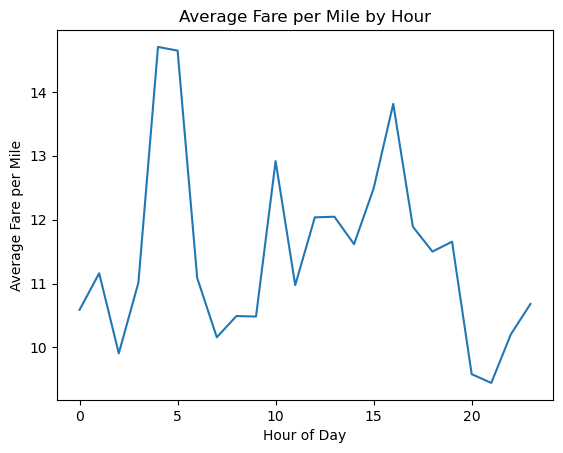

In [186]:
import matplotlib.pyplot as plt

plt.figure()
hourly_fare.plot()
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Hour")
plt.show()

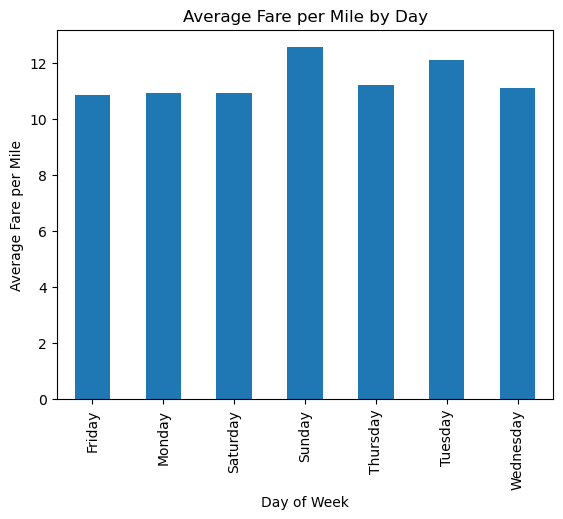

In [188]:
plt.figure()
daily_fare.plot(kind='bar')
plt.xlabel("Day of Week")
plt.ylabel("Average Fare per Mile")
plt.title("Average Fare per Mile by Day")
plt.show()
#for visually understanding the results

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [191]:
# Compare fare per mile for different vendors
# Create fare per mile column
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

# Remove invalid values (distance = 0 to avoid infinity)
df = df[df['trip_distance'] > 0]

# Group by VendorID and pickup_hour
vendor_hourly_fare = df.groupby(['VendorID', 'pickup_hour'])['fare_per_mile'].mean().reset_index()

# Display result
vendor_hourly_fare.head(20)

,VendorID,pickup_hour,fare_per_mile
0,1,0,6.775936
1,1,1,7.044005
2,1,2,6.988379
3,1,3,6.508216
4,1,4,7.588302
5,1,5,7.293020
6,1,6,6.634152
7,1,7,7.194156
8,1,8,8.065031
9,1,9,8.465451


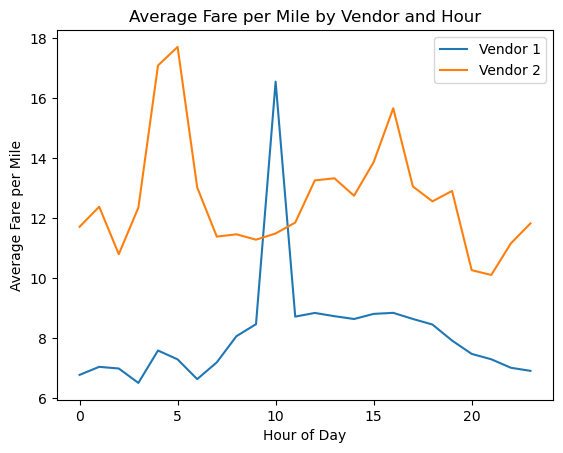

In [193]:
import matplotlib.pyplot as plt

for vendor in vendor_hourly_fare['VendorID'].unique():
    vendor_data = vendor_hourly_fare[vendor_hourly_fare['VendorID'] == vendor]
    
    plt.plot(vendor_data['pickup_hour'], vendor_data['fare_per_mile'], label=f'Vendor {vendor}')

plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile')
plt.title('Average Fare per Mile by Vendor and Hour')
plt.legend()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [195]:
# Defining distance tiers
def distance_tier(dist):
    if dist <= 2:
        return '0-2 miles'
    elif dist <= 5:
        return '2-5 miles'
    else:
        return '5+ miles'

# Create distance tier column
df['distance_tier'] = df['trip_distance'].apply(distance_tier)

# Remove zero distance to avoid division error
df_nonzero = df[df['trip_distance'] > 0].copy()

# Calculate fare per mile
df_nonzero['fare_per_mile'] = df_nonzero['fare_amount'] / df_nonzero['trip_distance']

# Group by vendor and distance tier
vendor_tier_fare = df_nonzero.groupby(
    ['VendorID', 'distance_tier']
)['fare_per_mile'].mean().reset_index()

# Display result
vendor_tier_fare

,VendorID,distance_tier,fare_per_mile
0,1,0-2 miles,10.634455
1,1,2-5 miles,6.378955
2,1,5+ miles,4.422504
3,2,0-2 miles,17.903077
4,2,2-5 miles,6.548410
5,2,5+ miles,4.502418


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [197]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

# Remove rows with zero fare to avoid division error
df_tip = df[df['fare_amount'] > 0].copy()

# Calculate tip percentage
df_tip['tip_percent'] = (df_tip['tip_amount'] / df_tip['fare_amount']) * 100

In [199]:
# Create distance bins
df_tip['distance_group'] = pd.cut(
    df_tip['trip_distance'],
    bins=[0, 2, 5, 10, 1000],
    labels=['0-2', '2-5', '5-10', '10+']
)

# Average tip by distance
tip_by_distance = df_tip.groupby('distance_group')['tip_percent'].mean()
tip_by_distance

distance_group
0-2     22.415844
2-5     18.757743
5-10    19.398931
10+     15.789250
Name: tip_percent, dtype: float64

In [201]:
# Average tip by passenger count
tip_by_passenger = df_tip.groupby('passenger_count')['tip_percent'].mean()
tip_by_passenger

passenger_count
1.0    20.917382
2.0    19.725986
3.0    19.024114
4.0    17.445196
5.0    20.500106
6.0    20.555222
Name: tip_percent, dtype: float64

In [203]:
# Average tip by hour
tip_by_hour = df_tip.groupby('pickup_hour')['tip_percent'].mean()
tip_by_hour

pickup_hour
0     20.508077
1     20.625301
2     20.623704
3     20.459764
4     18.286375
5     17.467478
6     18.442166
7     19.571571
8     20.029041
9     19.717923
10    19.250896
11    19.168779
12    19.120282
13    19.054640
14    19.032831
15    18.998561
16    20.914962
17    24.360268
18    22.223355
19    22.181292
20    21.496390
21    21.511269
22    21.305280
23    20.675190
Name: tip_percent, dtype: float64

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [205]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Low tip (<10%) and High tip (>25%)
low_tip = df_tip[df_tip['tip_percent'] < 10]
high_tip = df_tip[df_tip['tip_percent'] > 25]

# Compare main features
comparison = pd.DataFrame({
    'Low_Tip_Avg_Distance': [low_tip['trip_distance'].mean()],
    'High_Tip_Avg_Distance': [high_tip['trip_distance'].mean()],
    
    'Low_Tip_Avg_Passengers': [low_tip['passenger_count'].mean()],
    'High_Tip_Avg_Passengers': [high_tip['passenger_count'].mean()],
    
    'Low_Tip_Avg_Fare': [low_tip['fare_amount'].mean()],
    'High_Tip_Avg_Fare': [high_tip['fare_amount'].mean()],
    
    'Low_Tip_Peak_Hour': [low_tip['pickup_hour'].mode()[0]],
    'High_Tip_Peak_Hour': [high_tip['pickup_hour'].mode()[0]]
})

comparison

,Low_Tip_Avg_Distance,High_Tip_Avg_Distance,Low_Tip_Avg_Passengers,High_Tip_Avg_Passengers,Low_Tip_Avg_Fare,High_Tip_Avg_Fare,Low_Tip_Peak_Hour,High_Tip_Peak_Hour
0,3.92302,2.300427,1.430138,1.363337,21.877061,14.411812,15,18


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [207]:
# See how passenger count varies across hours and days
# Convert pickup datetime if not already done
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract hour and day name
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

In [209]:
# Avg passengers per hour
passenger_by_hour = df.groupby('pickup_hour')['passenger_count'].mean()

passenger_by_hour

pickup_hour
0     1.428781
1     1.433275
2     1.448857
3     1.452602
4     1.403275
5     1.293498
6     1.256787
7     1.275326
8     1.293510
9     1.318102
10    1.355781
11    1.366124
12    1.384170
13    1.385604
14    1.392608
15    1.411640
16    1.407087
17    1.392628
18    1.378560
19    1.390898
20    1.399751
21    1.426719
22    1.431243
23    1.424418
Name: passenger_count, dtype: float64

In [211]:
# Avg passengers per day
passenger_by_day = df.groupby('pickup_day')['passenger_count'].mean()

# Reorder days properly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
passenger_by_day = passenger_by_day.reindex(days_order)

passenger_by_day

pickup_day
Monday       1.361662
Tuesday      1.333712
Wednesday    1.330588
Thursday     1.344148
Friday       1.400836
Saturday     1.480120
Sunday       1.463987
Name: passenger_count, dtype: float64

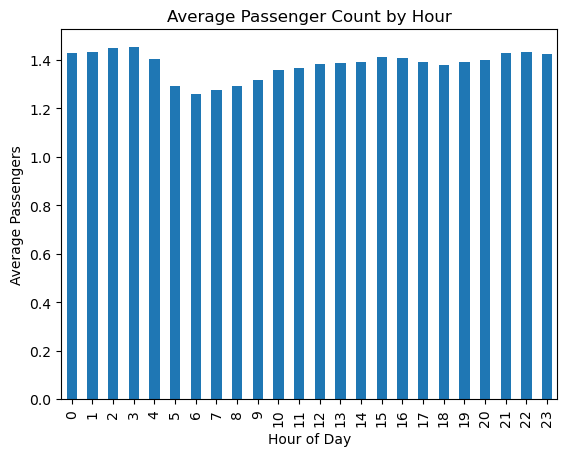

In [213]:
import matplotlib.pyplot as plt

passenger_by_hour.plot(kind='bar')
plt.title('Average Passenger Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passengers')
plt.show()

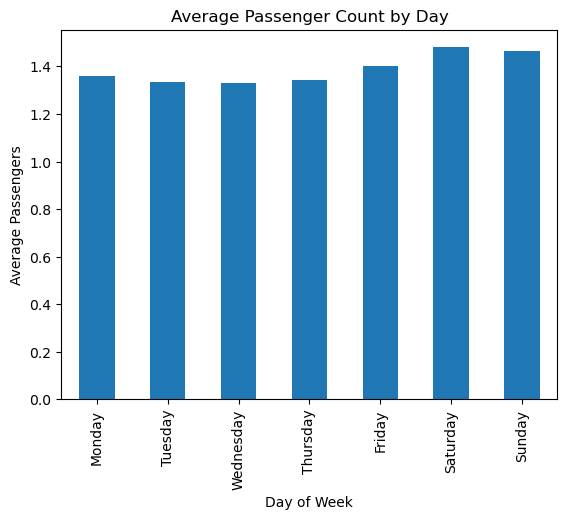

In [215]:
passenger_by_day.plot(kind='bar')
plt.title('Average Passenger Count by Day')
plt.xlabel('Day of Week')
plt.ylabel('Average Passengers')
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [218]:
# Merge trips with zones using pickup location
zones_with_trips = df.merge(
    zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

zones_with_trips.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,time_period,fare_per_mile,distance_tier,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,Night,4.186047,5+ miles,138.0,0.107467,0.000537,LaGuardia Airport,138.0,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,Night,6.370968,0-2 miles,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,Night,7.916667,0-2 miles,237.0,0.042213,0.000096,Upper East Side South,237.0,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,Night,12.037037,0-2 miles,143.0,0.054180,0.000151,Lincoln Square West,143.0,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,Night,4.859155,5+ miles,246.0,0.069467,0.000281,West Chelsea/Hudson Yards,246.0,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."


In [220]:
# How does passenger count vary across zones

# Average passenger count per zone
avg_passengers_zone = zones_with_trips.groupby(['LocationID', 'zone'])['passenger_count'].mean().reset_index()

# Rename for clarity
avg_passengers_zone.rename(columns={'passenger_count': 'avg_passenger_count'}, inplace=True)

avg_passengers_zone.head()

,LocationID,zone,avg_passenger_count
0,1.0,Newark Airport,1.312500
1,2.0,Jamaica Bay,1.000000
2,3.0,Allerton/Pelham Gardens,1.000000
3,4.0,Alphabet City,1.436259
4,5.0,Arden Heights,1.000000


In [222]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

zones_with_trips = df.merge(
    zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

In [224]:
# Calculate average passenger count per zone
avg_passengers = zones_with_trips.groupby('LocationID')['passenger_count'].mean().reset_index()

# Rename column
avg_passengers.rename(columns={'passenger_count': 'avg_passenger_count'},inplace=True)

In [226]:
# Merge average passenger count into zones
zones_with_passengers = zones.merge(avg_passengers,on='LocationID',how='left')

zones_with_passengers.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.312500
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",1.000000
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",1.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",1.436259
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",1.000000


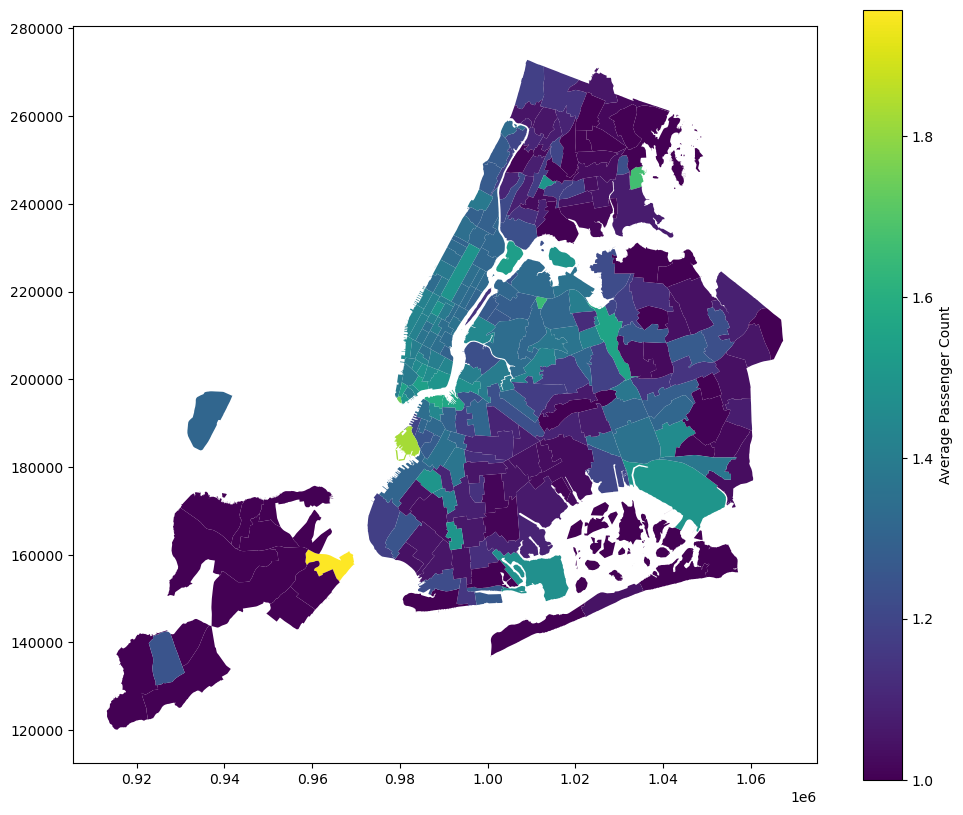

In [228]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_passengers.plot(column='avg_passenger_count',ax=ax,legend=True,legend_kwds={'label': 'Average Passenger Count'})

plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [232]:
# How often is each surcharge applied?
# List of surcharge columns
surcharge_cols = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'airport_fee'
]

# Count how often each surcharge is applied
surcharge_counts = {}

for col in surcharge_cols:
    surcharge_counts[col] = (df[col] > 0).sum()

surcharge_counts

{'extra': 1186371,
 'mta_tax': 1891868,
 'improvement_surcharge': 1903937,
 'congestion_surcharge': 1768852,
 'airport_fee': 167482}

In [234]:
total_trips = len(df)

surcharge_percentage = {}

for col in surcharge_cols:
    surcharge_percentage[col] = round((df[col] > 0).mean() * 100, 2)

surcharge_percentage

{'extra': 62.31,
 'mta_tax': 99.36,
 'improvement_surcharge': 99.99,
 'congestion_surcharge': 92.9,
 'airport_fee': 8.8}

In [236]:
extra_by_hour = df[df['extra'] > 0].groupby('pickup_hour').size()

extra_by_hour.sort_values(ascending=False)

pickup_hour
18    108812
21    104121
20    103132
17    102822
19     96921
22     95969
16     90670
23     75109
0      51311
15     36534
14     36099
1      34682
13     33490
12     32361
11     29938
10     28131
9      25404
2      22941
8      21616
7      15556
3      14781
4       8832
5       8797
6       8342
dtype: int64

In [237]:
extra_by_zone = df[df['extra'] > 0].groupby('PULocationID').size()

extra_by_zone.sort_values(ascending=False).head(10)


PULocationID
138    66336
161    57798
237    52445
132    49598
236    43279
162    42741
230    42650
142    40267
186    39093
163    35733
dtype: int64

In [239]:
# Define night hours
night_trips = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]

night_extra_pct = (night_trips['extra'] > 0).mean() * 100
day_extra_pct = (df['extra'] > 0).mean() * 100

night_extra_pct, day_extra_pct

(96.24453643635587, 62.30747051430654)

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.